In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import json


In [8]:
# Load the data to examine its structure
file_path = '/content/resnet18_UH_stage1_results.csv'
file_path = '/Users/birdy/Documents/mit-meng-thesis/results/resnet18_UH_stage1_results.csv'
file_path = '/Users/birdy/Documents/mit-meng-thesis/results/resnetAll_WHOI2014_stage3_results.csv'

df = pd.read_csv(file_path)
df['per_class_accuracy'] = df['per_class_accuracy']/100
# Display the first few rows of the dataframe to understand its structure
df.head()

,model_name,loss_function,optimizer,scheduler,learning_rate,batch_size,per_image_accuracy,per_class_accuracy,MACs,wall_time,history
0,resnet18-WHOI2014-train_padToSize,cross_entropy,adam,step,0.000001,512,0.947597,0.004003,1816.090624,7140.778560,"{'train_loss': [0.27381146976476806, 0.1992798..."
1,resnet18-WHOI2014-train_augmix,cross_entropy,adam,step,0.000001,512,0.954897,0.004016,1816.090624,48997.102580,"{'train_loss': [0.3176988322142156, 0.24254328..."
2,resnet50-WHOI2014-train_padToSize,cross_entropy,adam,step,0.000001,512,0.950897,0.003842,4098.432512,9157.508565,"{'train_loss': [0.3087030302730228, 0.22083314..."
3,resnet50-WHOI2014-train_augmix,cross_entropy,adam,step,0.000001,512,0.953786,0.003738,4098.432512,41533.949750,"{'train_loss': [0.36001100040174183, 0.2718978..."
4,resnet152-WHOI2014-train_padToSize,cross_entropy,adam,step,0.000001,512,0.950380,0.003829,11534.315010,14624.394420,"{'train_loss': [0.30830749692972564, 0.2289849..."


# Individual Training Plots

In [5]:
# for each model, plot the training an validation curves
history = df['history'][2]
model_name = df['model_name'][2]
history = history.replace("\'", "\"")
# load json object
history = json.loads(history)

In [9]:
history["val_loss"]

[0.2994332703795746,
 0.23526357489200694,
 0.2197443375332222,
 0.2194524784230258,
 0.21681564697528988,
 0.2160196931547782,
 5.806947810801135e+27]

In [3]:
# select only rows where optimizer == sgd
for row in df.iterrows():
  history = row[1]['history']
  model_name = row[1]['model_name']
  history = history.replace("\'", "\"")
  # load json object
  history = json.loads(history)

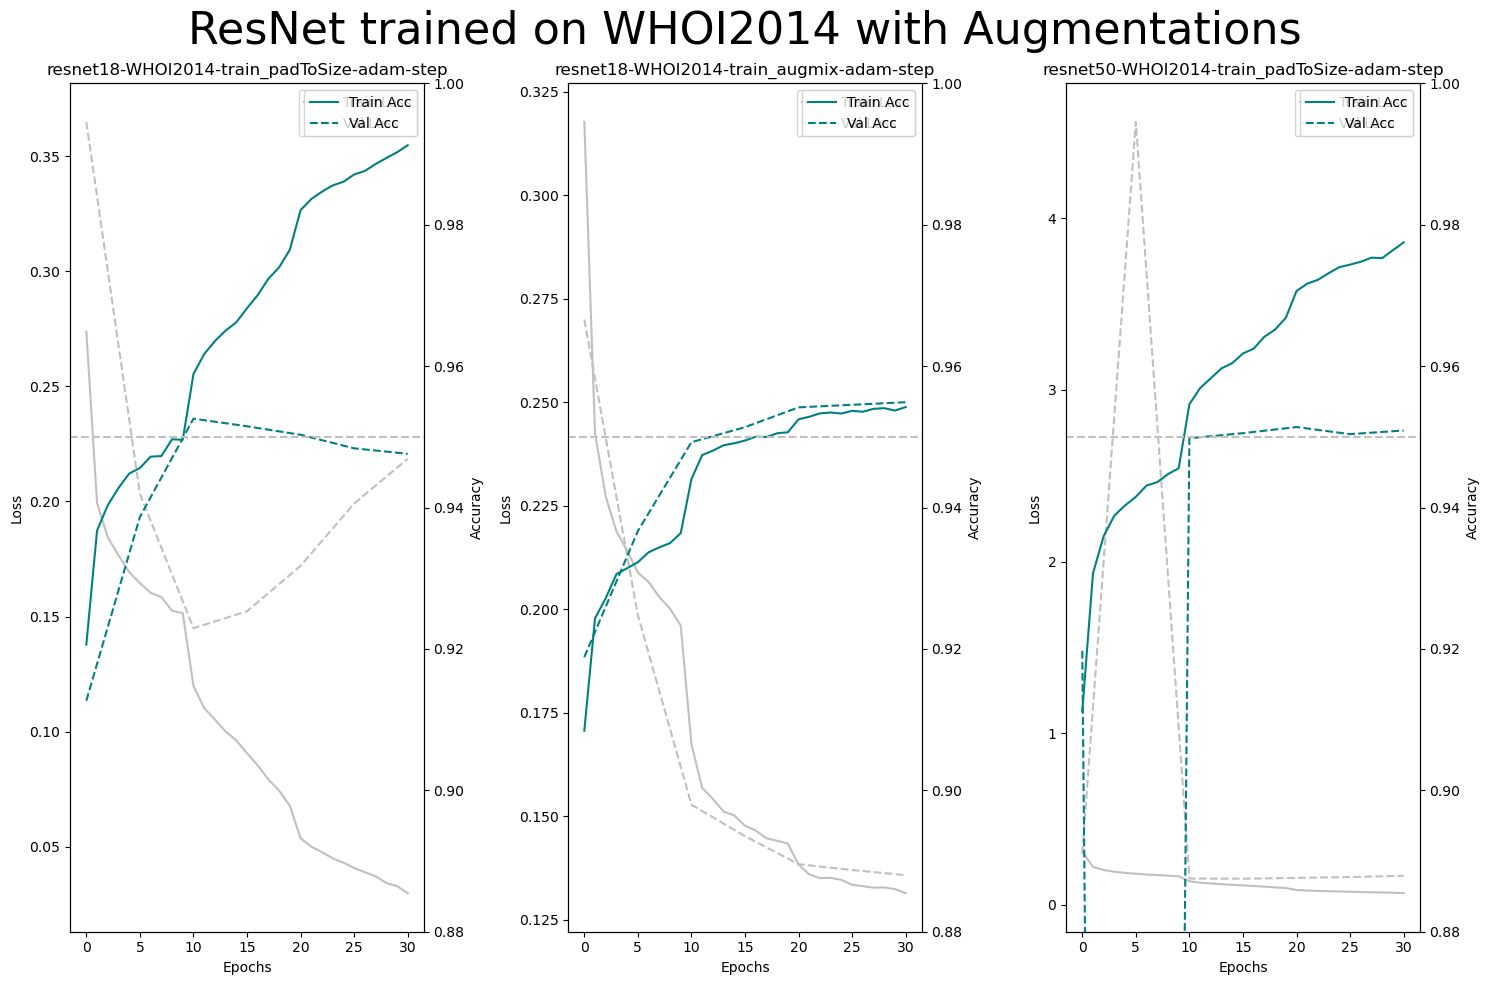

In [6]:
fig, axes = plt.subplots(1,3, figsize=(15,10))
# Plot Accuracy and Loss
for i, ax in zip(range(len(df)), axes):
  history = df['history'][i]
  model_name = df['model_name'][i]
  history = history.replace("\'", "\"")
  # load json object
  history = json.loads(history)

  # plot training and validation across epocs
  train_loss = history['train_loss']
  val_loss = history['val_loss']
  val_epochs = history['val_epochs']
  train_acc = history['train_acc']
  val_acc = history['val_acc']

  ax.set_title("Accuracy And Loss During Training")
  ax.plot(train_loss, label='Train Loss', color='silver')
  ax.plot(val_epochs, val_loss, label='Val Loss', color='silver', ls='--')
  # create another axis to plot accuracy on
  ax2 = ax.twinx()
  ax2.plot(train_acc, label='Train Acc', color='teal')
  ax2.plot(val_epochs, val_acc, label='Val Acc', color='teal', ls='--')
  ax.set_xlabel('Epochs')
  ax.set_ylabel('Loss')
  ax2.set_ylabel('Accuracy')
  ax2.axhline(y=.95, color='silver', linestyle='--')
  ax2.set_ylim([0.88, 1])
  ax2.legend()
  ax.legend()
  opt = df["optimizer"][i]
  sched = df["scheduler"][i]
  ax.set_title(f"{model_name}-{opt}-{sched}")

plt.suptitle("ResNet trained on WHOI2014 with Augmentations", fontsize=32)
plt.tight_layout()
plt.show()

## Single Plots 

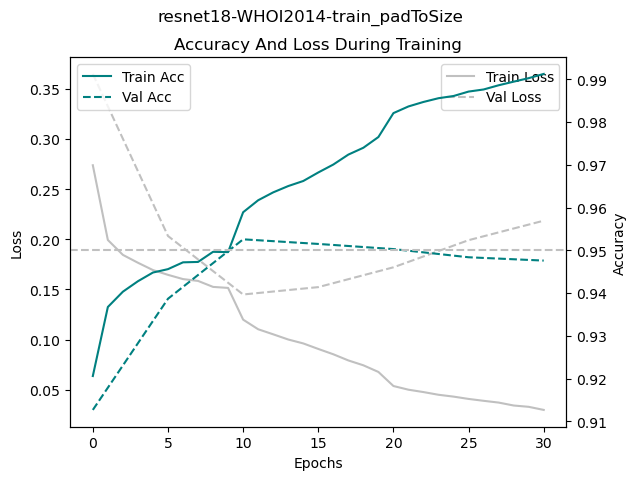

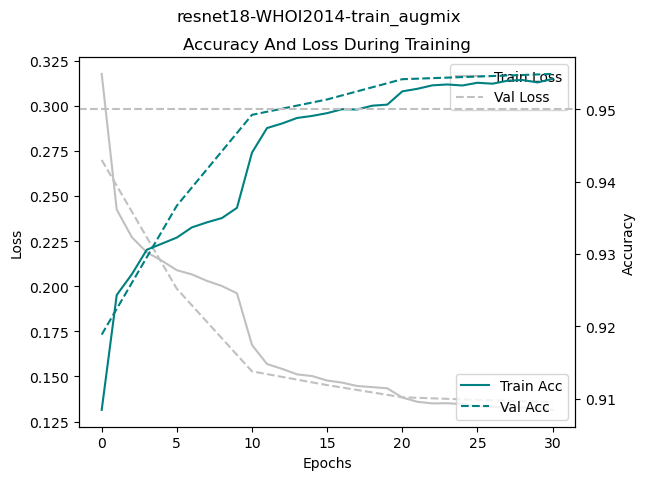

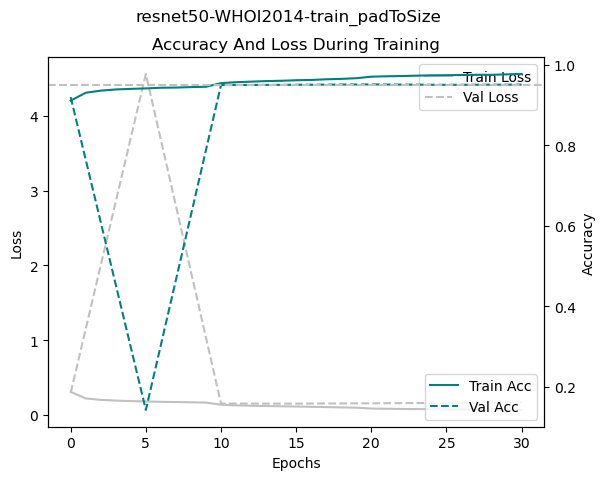

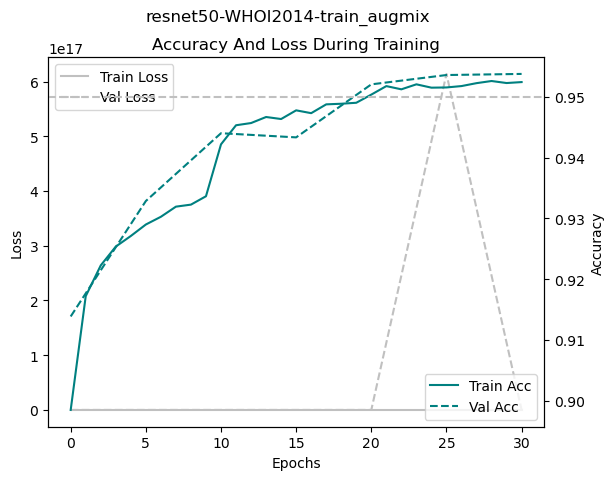

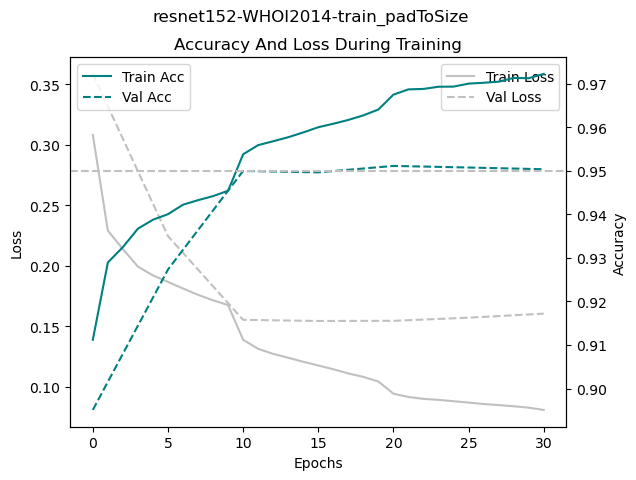

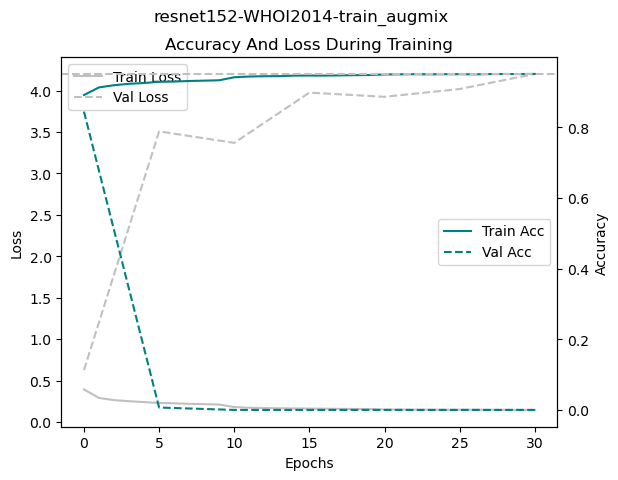

In [10]:
# Plot Accuracy and Loss
for i in range(len(df)):
  history = df['history'][i]
  model_name = df['model_name'][i]
  history = history.replace("\'", "\"")
  # load json object
  history = json.loads(history)

  # plot training and validation across epocs
  train_loss = history['train_loss']
  val_loss = history['val_loss']
  val_epochs = history['val_epochs']
  train_acc = history['train_acc']
  val_acc = history['val_acc']

  fig, ax = plt.subplots()
  ax.set_title("Accuracy And Loss During Training")
  ax.plot(train_loss, label='Train Loss', color='silver')
  ax.plot(val_epochs, val_loss, label='Val Loss', color='silver', ls='--')
  # create another axis to plot accuracy on
  ax2 = ax.twinx()
  ax2.plot(train_acc, label='Train Acc', color='teal')
  ax2.plot(val_epochs, val_acc, label='Val Acc', color='teal', ls='--')
  ax2.axhline(y=.95, color='silver', linestyle='--')

  ax.set_xlabel('Epochs')
  ax.set_ylabel('Loss')
  ax2.set_ylabel('Accuracy')
  ax2.legend()
  ax.legend()
  plt.suptitle(f"{model_name}")
  plt.show()

# Model Comparison Plots

## Accuracy of models

In [ ]:
df[['model_name', 'per_image_accuracy']].sort_values(by='per_image_accuracy', ascending=False)

,model_name,per_image_accuracy
7,resnet18-UH-adam-step-CrossEntropyLoss(),0.790130
6,resnet18-UH-adam-step-CrossEntropyLoss(),0.788898
3,resnet18-UH-sgd-cos-CrossEntropyLoss(),0.787817
12,resnet18-UH-adamw-step-CrossEntropyLoss(),0.786946
0,resnet18-UH-sgd-step-CrossEntropyLoss(),0.784903
2,resnet18-UH-sgd-cos-CrossEntropyLoss(),0.782921
9,resnet18-UH-adam-cos-CrossEntropyLoss(),0.780728
8,resnet18-UH-adam-cos-CrossEntropyLoss(),0.777905
15,resnet18-UH-adamw-cos-CrossEntropyLoss(),0.772708
14,resnet18-UH-adamw-cos-CrossEntropyLoss(),0.772528


## Per-Image vs Per-Class

<ipython-input-69-8e635e6d6933>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


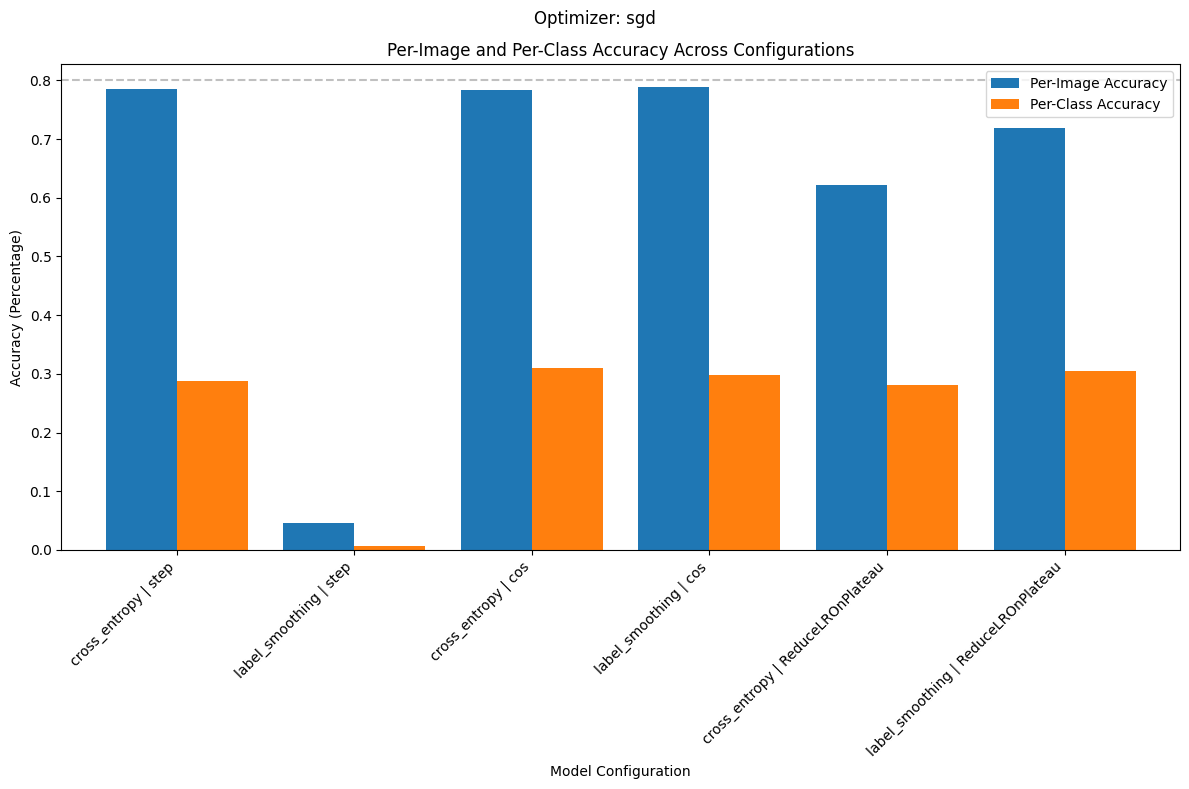

<ipython-input-69-8e635e6d6933>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


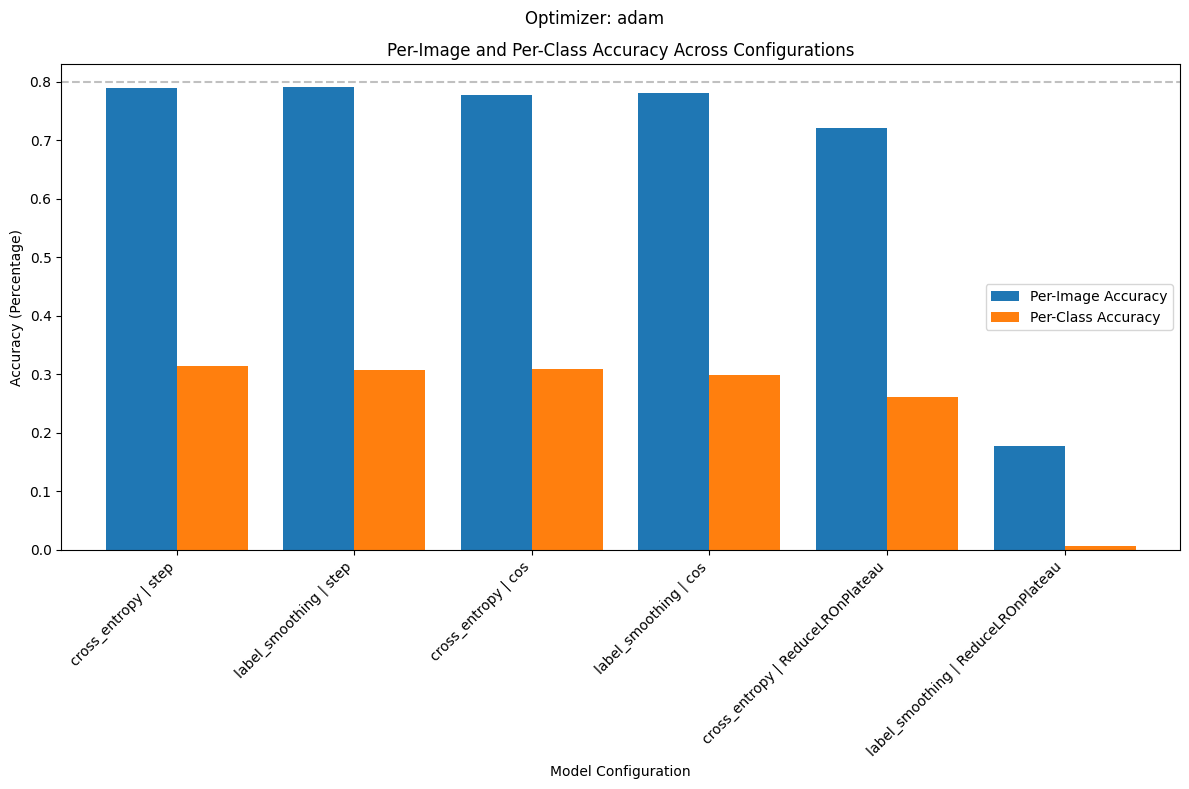

<ipython-input-69-8e635e6d6933>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


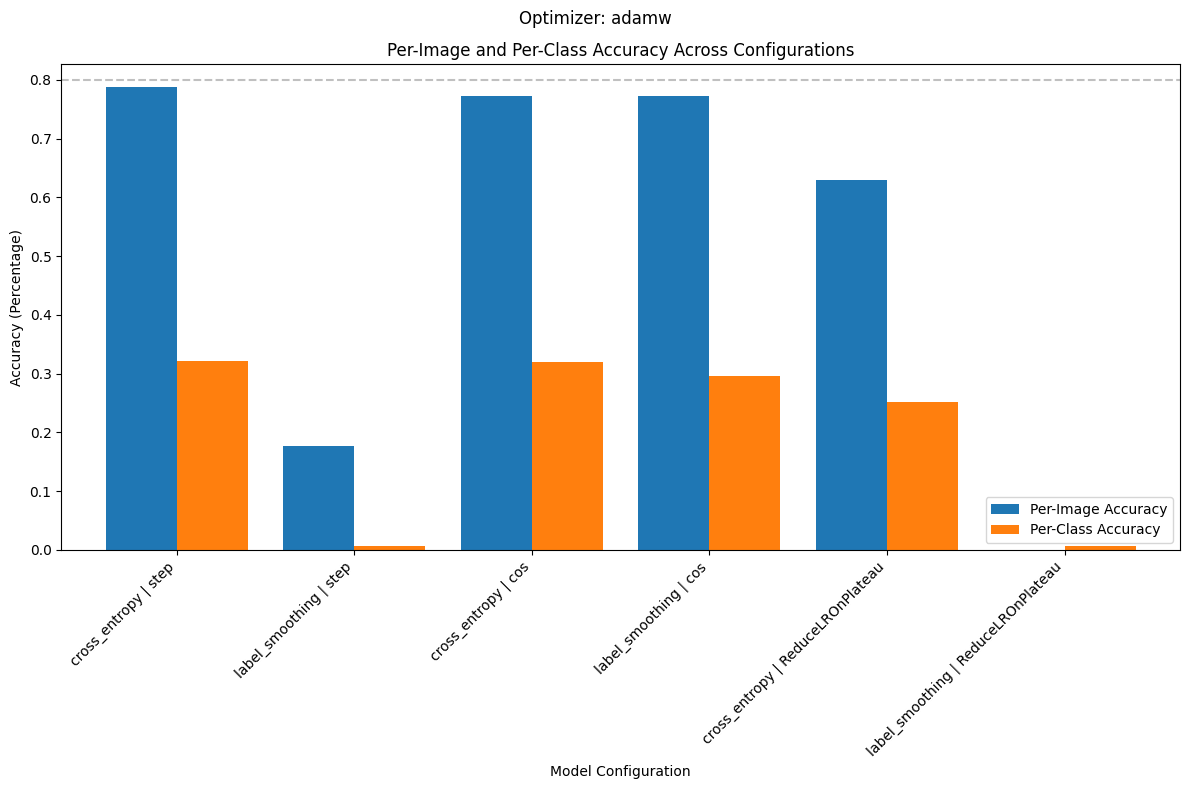

In [ ]:
# organize by optmizer still

for opt in df['optimizer'].unique():
  df_opt = df[df['optimizer'] == opt]
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']
  acc_data = df_opt[['Configuration','per_image_accuracy', 'per_class_accuracy']].set_index('Configuration')

  fig, ax = plt.subplots()
  # bar chart of accuracy and per class accuracy
  acc_data.plot(kind='bar', width=0.8, figsize=(12, 8), ax=ax)
  plt.title("Per-Image and Per-Class Accuracy Across Configurations")
  plt.xlabel("Model Configuration")
  plt.ylabel("Accuracy (Percentage)")
  plt.xticks(rotation=45, ha="right")
  plt.legend(["Per-Image Accuracy", "Per-Class Accuracy"])
  plt.suptitle(f"Optimizer: {opt}")
  plt.tight_layout()
  ax.axhline(y=.80, color='silver', linestyle='--')
  plt.show()


## Wall Time

<ipython-input-70-3e4e52d332b7>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


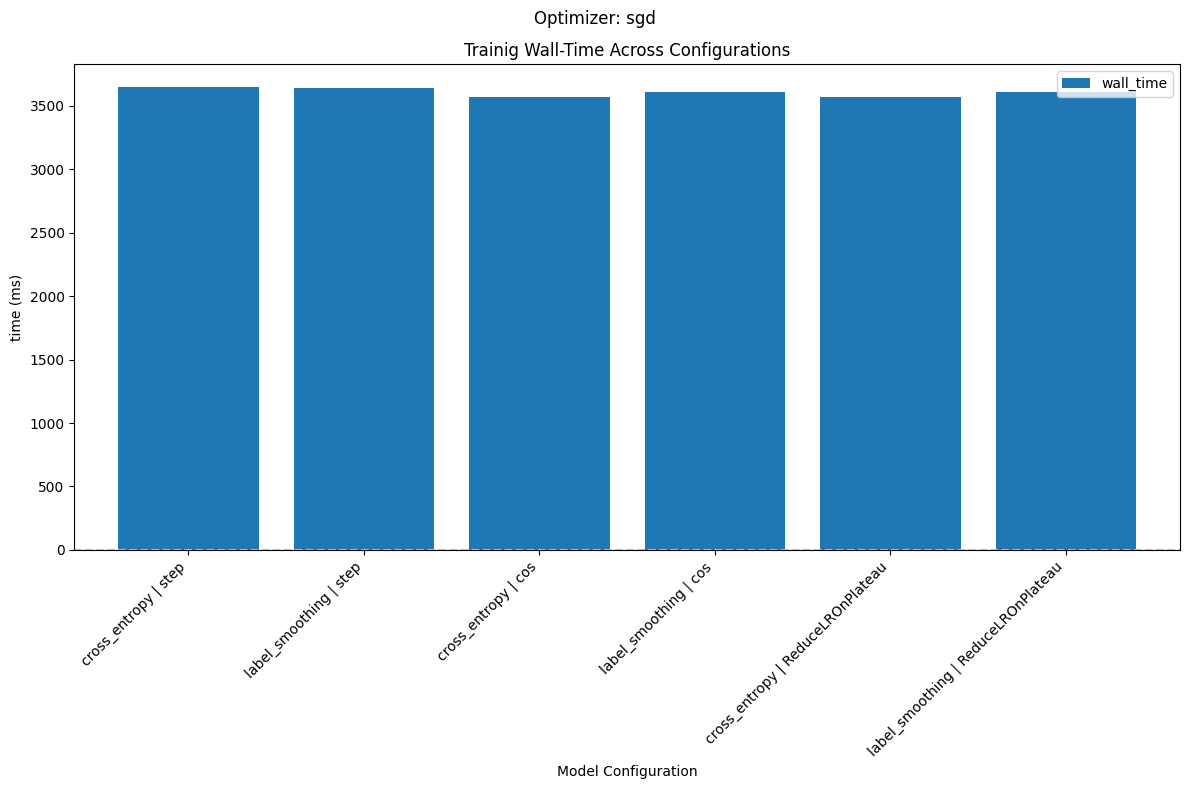

<ipython-input-70-3e4e52d332b7>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


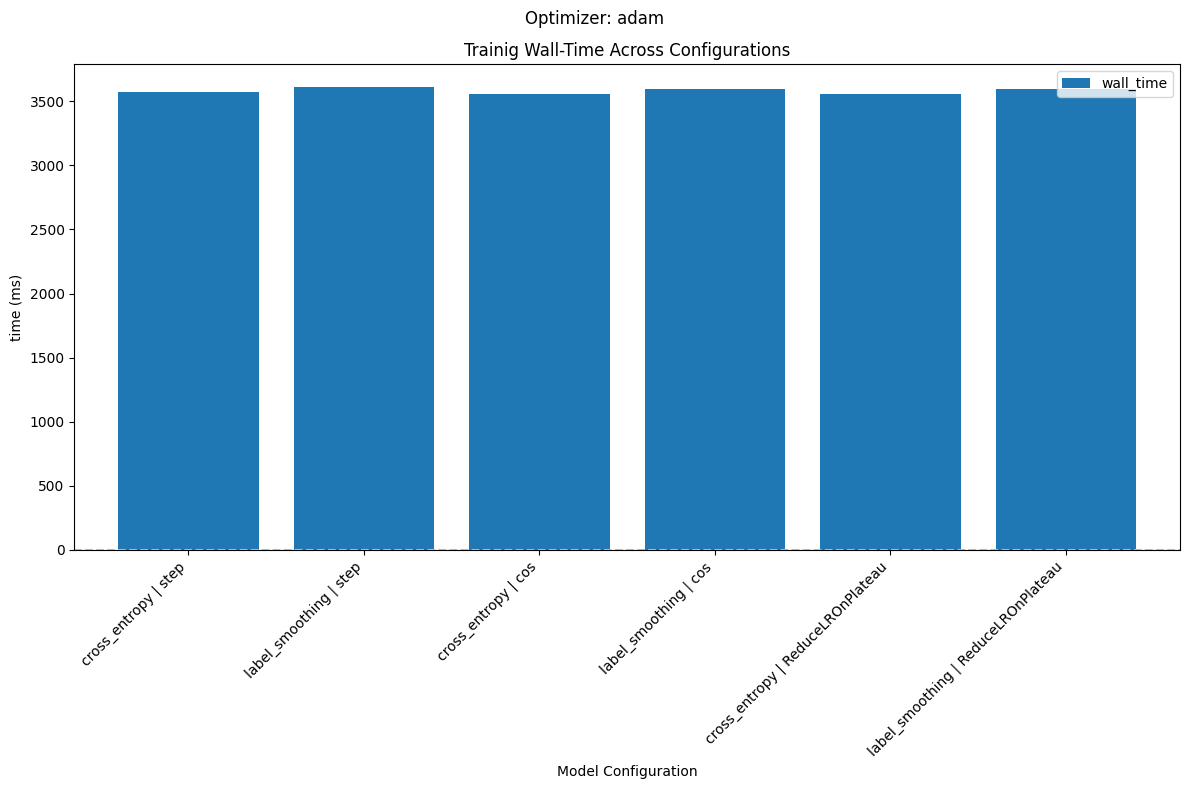

<ipython-input-70-3e4e52d332b7>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']


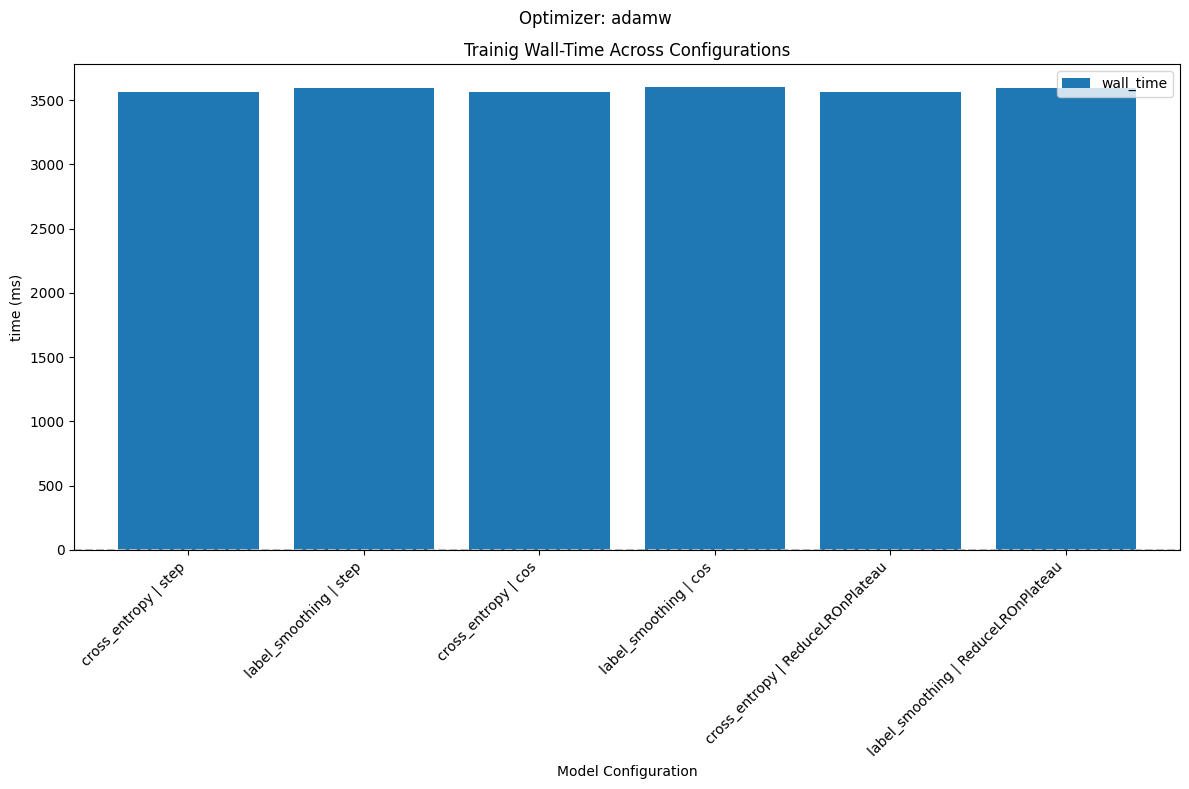

In [ ]:
# organize by optmizer still

for opt in df['optimizer'].unique():
  df_opt = df[df['optimizer'] == opt]
  df_opt['Configuration'] = df_opt['loss_function'] + ' | ' + df_opt['scheduler']
  acc_data = df_opt[['Configuration','wall_time']].set_index('Configuration')

  fig, ax = plt.subplots()
  # bar chart of accuracy and per class accuracy
  acc_data.plot(kind='bar', width=0.8, figsize=(12, 8), ax=ax)
  plt.title("Trainig Wall-Time Across Configurations")
  plt.xlabel("Model Configuration")
  plt.ylabel("time (ms)")
  plt.xticks(rotation=45, ha="right")
  plt.suptitle(f"Optimizer: {opt}")
  plt.tight_layout()
  ax.axhline(y=.80, color='silver', linestyle='--')
  plt.show()